In [1]:
import pickle
import numpy as np


# Load the pickle file
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_negative_entropy_selected_adducts.pkl', 'rb') as f:
    nist_data = pickle.load(f)

In [2]:
nist_data = list(nist_data)

{'Name': 'Ethylphosphonic acid',
 'Precursor_type': '[M-H-H2O]-',
 'Instrument_type': 'HCD',
 'Instrument': 'Thermo Finnigan Elite Orbitrap',
 'Ionization': 'ESI',
 'In-source_voltage': None,
 'Collision_gas': 'N2',
 'Collision_energy': 'NCE=65% 6eV',
 'Ion_mode': 'N',
 'InChIKey': 'GATNOFPXSDHULC-UHFFFAOYSA-N',
 'Formula': 'C2H7O3P',
 'MW': 110.0,
 'ExactMass': 110.013281,
 'CAS#': '6779-09-5',
 'NIST#': '1189639',
 'Num Peaks': 2,
 'precursor_mz': 90.9954,
 'peaks': array([[62.9645,  1.    ]], dtype=float32),
 'fragment_annotation': ['PO2/5.7pp', 'p/2.9pp']}

selected adducts are ... (ask huaxu)

## (A) Do simple spectra inflate similarity scores?
Compute similarity scores between randomly paired spectra.
Group them by  N (number of peaks).
Check if smaller  N leads to higher similarity by chance.

In [26]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt

def compute_random_similarity(nist_data, num_pairs=100, num_bootstrap=100, subset_size=50000):
    """
    Efficiently compute similarity scores between randomly paired spectra from different compounds,
    using bootstrapping to equalize sample size across peak groups.
    
    Parameters:
    nist_data (list): List of spectral dictionaries
    num_pairs (int): Fixed number of random pairs to compare per peak group per bootstrap iteration
    num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates
    subset_size (int): Number of entries to randomly sample from nist_data for faster processing
    
    Returns:
    dict: Bootstrapped mean similarity scores grouped by number of peaks
    """
    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)
    
    peak_groups = defaultdict(list)
    
    # Group spectra by number of peaks, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        if inchikey:
            n_peaks = spectrum['Num Peaks']
            peak_groups[n_peaks].append(spectrum)
    
    similarity_scores = defaultdict(list)
    
    for n_peaks, spectra in peak_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair
        
        # Convert to NumPy array for faster sampling
        spectra_array = np.array(spectra, dtype=object)
        
        # Precompute valid pairs
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array) 
            for spec2 in spectra_array[i+1:] if spec1['InChIKey'] != spec2['InChIKey']
        ]
        
        if len(valid_pairs) < num_pairs:
            continue  # Skip if not enough valid pairs
        
        # Perform bootstrapping
        for _ in range(num_bootstrap):
            selected_pairs = random.sample(valid_pairs, num_pairs)  # Sample pairs from precomputed list
            
            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da=0.05)
                for spec1, spec2 in selected_pairs
            ]
            similarity_scores[n_peaks].append(np.mean(scores) if scores else 0)
    
    # Compute final mean similarity per peak group across bootstrap iterations
    final_similarity_scores = {n: np.mean(scores) for n, scores in similarity_scores.items()}
    
    return final_similarity_scores

def plot_similarity_trend(mean_scores):
    """
    Plot mean similarity scores against the number of peaks.
    
    Parameters:
    mean_scores (dict): Mean similarity scores grouped by N
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(mean_scores.keys(), mean_scores.values(), color='blue', label='Mean Similarity')
    plt.plot(sorted(mean_scores.keys()), [mean_scores[n] for n in sorted(mean_scores.keys())], linestyle='--', color='red')
    plt.xlabel('Number of Peaks (N)')
    plt.ylabel('Mean Similarity Score')
    plt.title('Bootstrapped Mean Similarity vs. Number of Peaks')
    plt.legend()
    plt.grid()
    plt.show()

In [27]:
similarity_scores= compute_random_similarity(nist_data)


In [25]:
similarity_scores

{11: 0.017276411581113933,
 13: 0.016135687393173576,
 29: 0.040174791368143635,
 12: 0.01790036889832467,
 3: 0.014116211163997649,
 24: 0.04272063573842868,
 10: 0.014739139397256075,
 25: 0.046497132642222556,
 9: 0.013943238697908818,
 26: 0.043929982574880115,
 7: 0.010016994137987496,
 28: 0.046360915505606684,
 19: 0.025854858169537035,
 15: 0.023470226827599108,
 16: 0.026175334668401627,
 38: 0.042338931659590455,
 20: 0.024570978793259708,
 14: 0.02194853917354718,
 6: 0.011028308938816187,
 5: 0.011706050777584315,
 4: 0.011524569909349087,
 8: 0.01408433219961822,
 18: 0.02892382250646129,
 17: 0.026256614243276414,
 23: 0.028784754409715528,
 22: 0.03339107888679951,
 2: 0.007942610318660736,
 27: 0.056068361361771825,
 35: 0.04842158058966509,
 37: 0.049696107386909424,
 34: 0.04638919368715957,
 49: 0.06974063488312064,
 33: 0.06023840240602382,
 36: 0.053662854775441804,
 39: 0.0507343106613122,
 32: 0.047819782375888895,
 31: 0.049996900611110034,
 44: 0.05839203440224

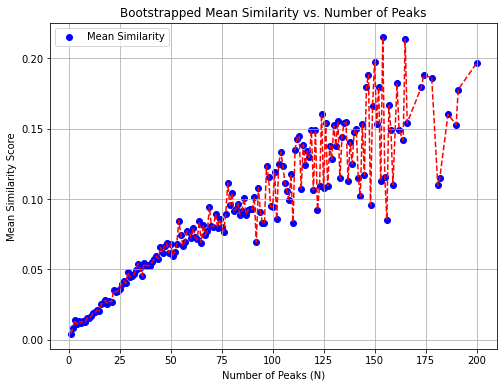

In [28]:
plot_similarity_trend(similarity_scores)

### result not as expected

the similarity score seems to go up with increased number of peaks

# (B) compute spectral entropy and group by spectral entropy rather than ion number

In [33]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt

def compute_random_similarity(nist_data, num_pairs=100, num_bootstrap=100, subset_size=10000):
    """
    Efficiently compute similarity scores between randomly paired spectra from different compounds,
    using bootstrapping to equalize sample size across spectral entropy groups.
    
    Parameters:
    nist_data (list): List of spectral dictionaries
    num_pairs (int): Fixed number of random pairs to compare per entropy group per bootstrap iteration
    num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates
    subset_size (int): Number of entries to randomly sample from nist_data for faster processing
    
    Returns:
    dict: Bootstrapped mean similarity scores grouped by spectral entropy
    """
    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)
    
    entropy_groups = defaultdict(list)
    
    # Group spectra by spectral entropy, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0:
            entropy = me.calculate_spectral_entropy(np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05)
            entropy_groups[round(entropy)].append(spectrum)
    
    similarity_scores = defaultdict(list)
    
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair
        
        # Convert to NumPy array for faster sampling
        spectra_array = np.array(spectra, dtype=object)
        
        # Precompute valid pairs
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array) 
            for spec2 in spectra_array[i+1:] if spec1['InChIKey'] != spec2['InChIKey']
        ]
        
        if len(valid_pairs) < num_pairs:
            continue  # Skip if not enough valid pairs
        
        # Perform bootstrapping
        for _ in range(num_bootstrap):
            selected_pairs = random.sample(valid_pairs, num_pairs)  # Sample pairs from precomputed list
            
            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da=0.05)
                for spec1, spec2 in selected_pairs
            ]
            similarity_scores[entropy].append(np.mean(scores) if scores else 0)
    
    # Compute final mean similarity per entropy group across bootstrap iterations
    final_similarity_scores = {entropy: np.mean(scores) for entropy, scores in similarity_scores.items()}
    
    return final_similarity_scores

def plot_similarity_trend(mean_scores):
    """
    Plot mean similarity scores against spectral entropy.
    
    Parameters:
    mean_scores (dict): Mean similarity scores grouped by spectral entropy
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(mean_scores.keys(), mean_scores.values(), color='blue', label='Mean Similarity')
    plt.plot(sorted(mean_scores.keys()), [mean_scores[e] for e in sorted(mean_scores.keys())], linestyle='--', color='red')
    plt.xlabel('Spectral Entropy')
    plt.ylabel('Mean Similarity Score')
    plt.title('Bootstrapped Mean Similarity vs. Spectral Entropy')
    plt.legend()
    plt.grid()
    plt.show()

In [34]:
similarity_scores_entropy = compute_random_similarity(nist_data)

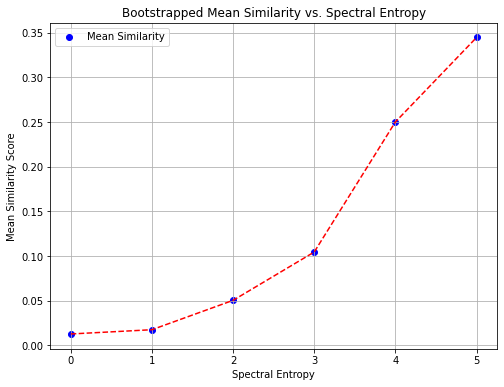

In [35]:
plot_similarity_trend(similarity_scores_entropy)

In [51]:
peak_match = compute_peak_matches(nist_data)

In [50]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt

def compute_peak_matches(nist_data, num_pairs=100, num_bootstrap=100, subset_size=5000, tolerance=0.05):
    """
    Efficiently count peak matches between randomly paired spectra from different compounds,
    using bootstrapping to equalize sample size across spectral entropy groups.
    
    Parameters:
    nist_data (list): List of spectral dictionaries
    num_pairs (int): Fixed number of random pairs to compare per entropy group per bootstrap iteration
    num_bootstrap (int): Number of bootstrap iterations to stabilize peak match estimates
    subset_size (int): Number of entries to randomly sample from nist_data for faster processing
    tolerance (float): Mass tolerance in Da to count matching peaks
    
    Returns:
    dict: Bootstrapped mean peak match fractions grouped by spectral entropy
    """
    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)
    
    entropy_groups = defaultdict(list)
    
    # Group spectra by spectral entropy, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0:
            entropy = me.calculate_spectral_entropy(np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05)
            entropy_groups[round(entropy)].append(spectrum)
    
    peak_match_fractions = defaultdict(list)
    
    def count_peak_matches(peaks1, peaks2, tolerance):
        """
        Efficiently count the number of peaks in peaks1 that have a match in peaks2 within the given tolerance.
        Uses sorting and binary search to speed up matching.

        Parameters:
        peaks1 (list): List of (mass, intensity) tuples for spectrum 1
        peaks2 (list): List of (mass, intensity) tuples for spectrum 2
        tolerance (float): Mass tolerance in Da for counting matches

        Returns:
        float: Fraction of peaks in peaks1 that have a match in peaks2
        """
        peaks1_masses = np.array([p[0] for p in peaks1])
        peaks2_masses = np.array([p[0] for p in peaks2])

        # Sort peaks2 for efficient binary search
        peaks2_masses.sort()

        match_count = 0
        for m1 in peaks1_masses:
            idx = np.searchsorted(peaks2_masses, m1)  # Find the insertion index
            # Check neighbors within tolerance
            if (idx < len(peaks2_masses) and abs(peaks2_masses[idx] - m1) <= tolerance) or \
               (idx > 0 and abs(peaks2_masses[idx - 1] - m1) <= tolerance):
                match_count += 1

        return match_count / max(len(peaks1_masses), 1)  # Normalize by peaks1 length

    
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair
        
        # Convert to NumPy array for faster sampling
        spectra_array = np.array(spectra, dtype=object)
        
        # Precompute valid pairs
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array) 
            for spec2 in spectra_array[i+1:] if spec1['InChIKey'] != spec2['InChIKey']
        ]
        
        if len(valid_pairs) < num_pairs:
            continue  # Skip if not enough valid pairs
        
        # Perform bootstrapping
        for _ in range(num_bootstrap):
            selected_pairs = random.sample(valid_pairs, num_pairs)  # Sample pairs from precomputed list
            match_fractions = []
            
            for spec1, spec2 in selected_pairs:
                match_fractions.append(count_peak_matches(spec1['peaks'], spec2['peaks'], tolerance))
            
            peak_match_fractions[entropy].append(np.mean(match_fractions) if match_fractions else 0)
    
    # Compute final mean peak match fraction per entropy group across bootstrap iterations
    final_peak_match_fractions = {entropy: np.mean(matches) for entropy, matches in peak_match_fractions.items()}
    
    return final_peak_match_fractions

def plot_peak_match_trend(peak_matches):
    """
    Plot fraction of matching peaks against spectral entropy.
    
    Parameters:
    peak_matches (dict): Fraction of matching peaks grouped by spectral entropy
    """
    plt.figure(figsize=(8, 6))
    plt.xlabel('Spectral Entropy')
    plt.ylabel('Fraction of Peak Matches')
    plt.scatter(peak_matches.keys(), peak_matches.values(), color='red', label='Peak Match Fraction')
    plt.plot(sorted(peak_matches.keys()), [peak_matches[e] for e in sorted(peak_matches.keys())], linestyle='--', color='red')
    plt.title('Bootstrapped Peak Matches vs. Spectral Entropy')
    plt.legend()
    plt.show()

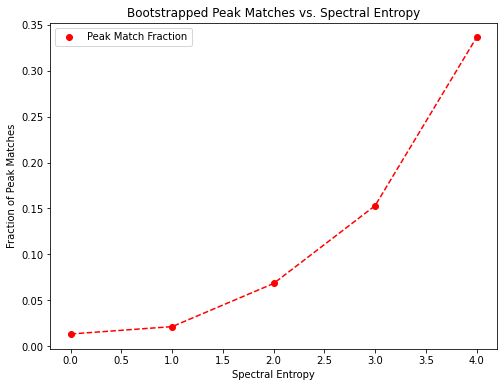

In [52]:
plot_peak_match_trend(peak_match)

### What I found
 - higher spectral entropy, higher fraction of peak matches for random pairs
 - null distribution for different entropy spectrum are different
     - higher spectral entropy leads to a higher fraction of peak matches

## Visualize Null Distributions

In [7]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns


def compute_random_similarity(nist_data, num_pairs=100, num_bootstrap=100, subset_size=10000):
    """
    Efficiently compute similarity scores between randomly paired spectra from different compounds,
    using bootstrapping to equalize sample size across spectral entropy groups.

    Parameters:
    nist_data (list): List of spectral dictionaries
    num_pairs (int): Fixed number of random pairs to compare per entropy group per bootstrap iteration
    num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates
    subset_size (int): Number of entries to randomly sample from nist_data for faster processing

    Returns:
    dict: Null distributions of similarity scores grouped by spectral entropy
    """
    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by spectral entropy, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0:
            entropy = me.calculate_spectral_entropy(np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05)
            entropy_groups[round(entropy)].append(spectrum)

    # Precompute valid pairs for each entropy group
    valid_pairs_per_entropy = {}
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair

        spectra_array = np.array(spectra, dtype=object)
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:] if spec1['InChIKey'] != spec2['InChIKey']
        ]

        if valid_pairs:
            valid_pairs_per_entropy[entropy] = valid_pairs

    # Determine the minimum number of valid pairs across all entropy groups
    min_num_pairs = min(len(pairs) for pairs in valid_pairs_per_entropy.values()) if valid_pairs_per_entropy else 0

    # Ensure consistent sample size across entropy groups
    null_distributions = defaultdict(list)
    for entropy, valid_pairs in valid_pairs_per_entropy.items():
        for _ in range(num_bootstrap):
            # Sample with replacement if not enough pairs
            if len(valid_pairs) < min_num_pairs:
                selected_pairs = random.choices(valid_pairs, k=min_num_pairs)
            else:
                selected_pairs = random.sample(valid_pairs, min_num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da=0.05)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)

    return null_distributions


def visualize_null_distributions(null_distributions):
    """
    Visualize null distributions of similarity scores grouped by spectral entropy.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    """
    for entropy, scores in null_distributions.items():
        plt.figure(figsize=(8, 5))
        sns.histplot(scores, kde=True, bins=30, color='blue', alpha=0.6)
        plt.xlabel('Similarity Score')
        plt.ylabel('Frequency')
        plt.title(f'Null Distribution of Similarity Scores (Entropy {entropy})')
        plt.grid(axis='y')
        plt.show()


def calculate_p_value(observed_similarity, null_distribution):
    """
    Calculate one-sided p-value for a similarity score.

    Parameters:
    observed_similarity (float): Similarity score to test
    null_distribution (list or numpy.ndarray): Null distribution of similarity scores

    Returns:
    float: One-sided p-value
    """
    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value


def calculate_p_values_for_all_entropy(null_distributions, observed_similarity=0.75):
    """
    Calculate p-values for a given observed similarity score across all entropy groups.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarity (float): The observed similarity score to calculate p-values for

    Returns:
    dict: P-values for each entropy group
    """
    p_values = {
        entropy: calculate_p_value(observed_similarity, null_distribution)
        for entropy, null_distribution in null_distributions.items()
    }
    return p_values


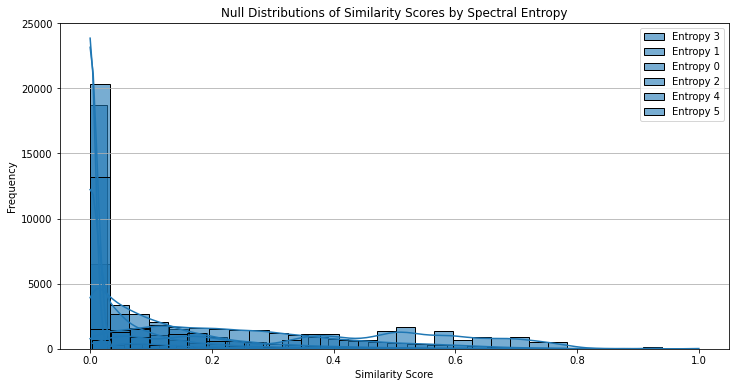

In [4]:
null = compute_random_similarity(nist_data)


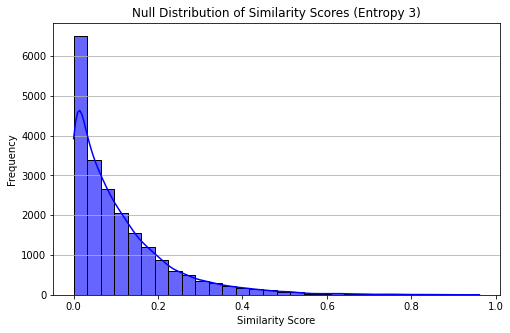

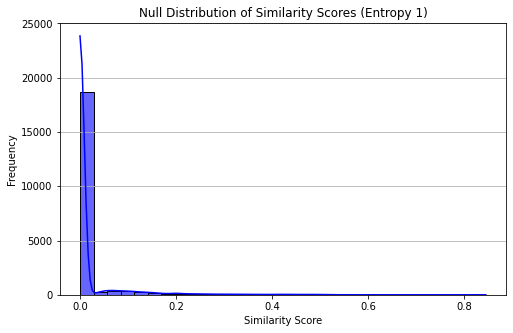

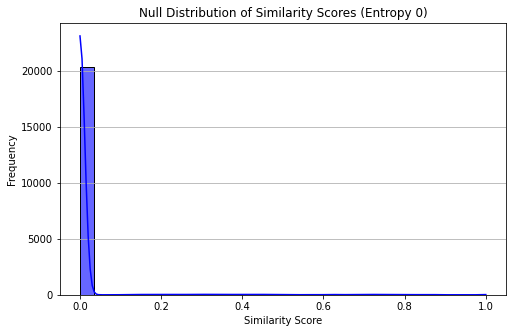

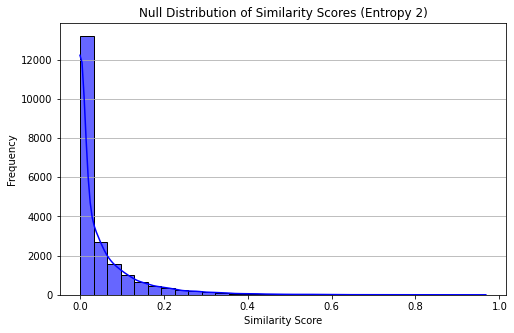

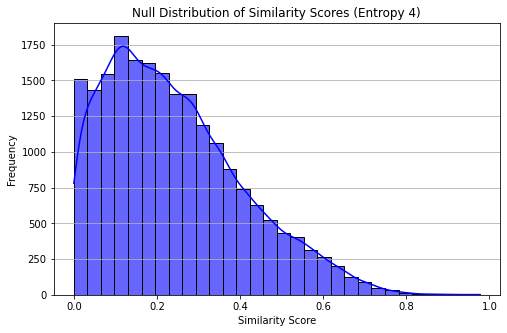

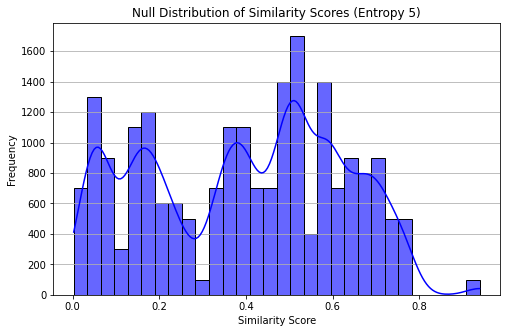

In [8]:
visualize_null_distributions(null)

In [6]:
calculate_p_values_for_all_entropy(null, observed_similarity=0.5)

{3: 0.013253588516746411,
 1: 0.0022488038277511963,
 0: 0.010574162679425837,
 2: 0.00507177033492823,
 4: 0.08483253588516747,
 5: 0.3827751196172249}